In [1]:
import pandas as pd
import os
import pyprojroot, sys
from pyprojroot.criterion import has_file
sys.path.insert(0, str(pyprojroot.find_root(has_file("pyproject.toml"))))

from dotenv import load_dotenv,find_dotenv

# load_dotenv()

env_file_path = find_dotenv()
print("当前加载的 .env 文件路径:", env_file_path)
# 2. 加载该文件
load_dotenv(env_file_path, override=True)

当前加载的 .env 文件路径: /workspace/worker/pj/Chrono/genuis/mizar/.env


True

In [2]:
from lib.iux001 import fetch_data, aggregation_data,merging_data1
from lib.aux001 import calc_expression
from lib.cux001 import FactorEvaluate1

/workspace/worker/pj/Chrono/genuis/mizar
/workspace/worker/pj/Chrono/genuis/mizar/config/contract.toml


In [4]:
method = 'ricso2'
instruments = 'hcb'
period = 5
task_id = '113001'
datasets = ['train','val']

In [5]:
total_data = fetch_data(method=method,
                        instruments=instruments,
                        task_id=task_id,
                        datasets=datasets)

/workspace/worker/pj/Chrono/genuis/mizar/records/ricso2/hcb/basic/train_data.feather
/workspace/worker/pj/Chrono/genuis/mizar/records/ricso2/hcb/basic/val_data.feather
/workspace/worker/pj/Chrono/genuis/mizar/records/ricso2/hcb/returns/train_returns.feather
/workspace/worker/pj/Chrono/genuis/mizar/records/ricso2/hcb/returns/val_returns.feather


In [5]:
#market_data = total_data[['trade_time','code','open','close','high','low','volume','openint','value','value']]

In [6]:
total_data.head()

,trade_time,code,fz002_1_2_1,fz002_10_15_1,fz002_1_2_0,fz002_10_15_0,fz002_5_10_1,fz002_5_10_0,fz002_2_3_1,fz002_2_3_0,...,low,vwap,nxt1_ret_1h,nxt1_ret_2h,nxt1_ret_3h,nxt1_ret_5h,nxt1_ret_10h,nxt1_ret_15h,time_weight,equal_weight
0,2014-03-25 09:00:00,HC,0.001659,0.000108,0.001135,0.000040,0.000265,0.000112,0.001131,0.000993,...,3298.01516,3310.173343,0.000126,-0.001270,-0.002569,-0.003182,-0.001817,-0.002098,-0.000789,-0.001238
1,2014-03-25 09:01:00,HC,0.000553,0.000128,0.001135,0.000048,0.000292,0.000138,0.000810,0.000789,...,3307.94296,3312.964429,-0.001396,-0.002695,-0.003047,-0.003539,-0.002150,-0.002673,-0.002104,-0.002379
2,2014-03-25 09:02:00,HC,0.000184,0.000138,0.000000,0.000057,0.000285,0.000161,0.000486,0.000446,...,3309.92852,3313.381350,-0.001299,-0.001651,-0.001912,-0.001059,0.000320,-0.001877,-0.001519,-0.001621
3,2014-03-25 09:03:00,HC,0.000061,0.000142,0.000000,0.000065,0.000264,0.000167,0.000270,0.000223,...,3305.95740,3308.758875,-0.000352,-0.000613,-0.000844,0.000343,0.002216,-0.000759,-0.000521,-0.000603
4,2014-03-25 09:04:00,HC,-0.000199,0.000140,-0.000098,0.000073,0.000229,0.000175,0.000063,-0.000028,...,3301.98628,3304.463041,-0.000261,-0.000492,0.000592,0.000543,0.001927,0.000003,-0.000196,-0.000054


In [7]:
#market_data.tail()

In [8]:
#market_data.shape

In [9]:
#total_data[['trade_time','code','tc014_1_2_5_0','oi004_1_3_1','tn008_1_3_1_2','tn008_1_3_1_3']]

In [10]:
total_data.filter(regex="^nxt1").columns.to_list()
nxt1_columns = total_data.filter(regex="^nxt1").columns.to_list()
basic_columns = [
        'close', 'high', 'low', 'open', 'volume'
        #, 'value', 'openint'
    ]

regex_pattern = r'^[^_]+_(5|10|15)_.*'
not_columns = total_data.columns[total_data.columns.str.contains(
        regex_pattern)]

factor_columns = [
        col for col in total_data.columns
        if col not in ['trade_time', 'code'] + nxt1_columns + basic_columns +
        not_columns.tolist()
    ]#[0:100]

In [11]:
#total_data
basic_columns

['close', 'high', 'low', 'open', 'volume']

In [12]:
# total_data = total_data[['trade_time', 'code'] + factor_columns + basic_columns + ["nxt1_ret_{}h".format(period)]]
total_data = total_data[['trade_time', 'code'] + factor_columns  + ["nxt1_ret_{}h".format(period)]]
total_data.head()

,trade_time,code,fz002_1_2_1,fz002_1_2_0,fz002_2_3_1,fz002_2_3_0,gd002_1_2_1,gd002_1_2_0,gd002_2_3_1,gd002_2_3_0,...,tf022_1_2_1,tf022_1_2_0,tf022_2_3_1,tf022_2_3_0,openint,value,vwap,time_weight,equal_weight,nxt1_ret_5h
0,2014-03-25 09:00:00,HC,0.001659,0.001135,0.001131,0.000993,0.019618,0.054348,0.089813,0.044852,...,3300.317467,3300.823222,3301.276337,3304.810508,48314.0,63817480.0,3310.173343,-0.000789,-0.001238,-0.003182
1,2014-03-25 09:01:00,HC,0.000553,0.001135,0.000810,0.000789,0.710280,0.468923,0.429484,0.258352,...,3308.768197,3311.452971,3306.058223,3303.897364,48004.0,56396280.0,3312.964429,-0.002104,-0.002379,-0.003539
2,2014-03-25 09:02:00,HC,0.000184,0.000000,0.000486,0.000446,0.827579,1.000000,0.615699,0.511613,...,3311.507013,3309.226509,3309.754551,3309.120257,48272.0,18155880.0,3313.381350,-0.001519,-0.001621,-0.001059
3,2014-03-25 09:03:00,HC,0.000061,0.000000,0.000270,0.000223,0.972692,1.000000,0.814651,0.769286,...,3305.572945,3304.553416,3307.447638,3308.158853,49822.0,79321160.0,3308.758875,-0.000521,-0.000603,0.000343
4,2014-03-25 09:04:00,HC,-0.000199,-0.000098,0.000063,-0.000028,0.987687,1.000000,0.904144,1.000000,...,3302.237244,3303.390294,3303.734203,3302.847650,49330.0,38211120.0,3304.463041,-0.000196,-0.000054,0.000543


In [13]:
expression = "MA(30,MDEMA(30, 'iv004_1_1_2_2_1'))"

In [14]:
%%time
factor_data = calc_expression(expression=expression,
                              total_data=total_data.set_index('trade_time'))

CPU times: user 1min 8s, sys: 19.3 s, total: 1min 28s
Wall time: 1min 28s


In [15]:
factor_data.tail()

,trade_time,transformed,code
874453,2025-04-30 14:55:00,0.000051,HC
874454,2025-04-30 14:56:00,0.000050,HC
874455,2025-04-30 14:57:00,0.000050,HC
874456,2025-04-30 14:58:00,0.000053,HC
874457,2025-04-30 14:59:00,0.000055,HC


In [16]:
#factor_data.merge(total_data[['trade_time','code','nxt1_ret_15h']], on=['trade_time','code'])

In [17]:
dt = merging_data1(factor_data=factor_data,
                      returns_data=total_data,
                      period=period)

In [18]:
dt.tail(20)

,trade_time,transformed,code,nxt1_ret_5h
874438,2025-04-30 14:40:00,0.000028,HC,-0.001100
874439,2025-04-30 14:41:00,0.000035,HC,-0.000585
874440,2025-04-30 14:42:00,0.000040,HC,-0.000411
874441,2025-04-30 14:43:00,0.000044,HC,-0.000457
874442,2025-04-30 14:44:00,0.000047,HC,-0.000179
874443,2025-04-30 14:45:00,0.000050,HC,0.000353
874444,2025-04-30 14:46:00,0.000051,HC,0.000375
874445,2025-04-30 14:47:00,0.000052,HC,-0.000247
874446,2025-04-30 14:48:00,0.000054,HC,-0.000372
874447,2025-04-30 14:49:00,0.000057,HC,-0.000320


In [19]:
evaluate1 = FactorEvaluate1(factor_data=dt,
                                factor_name='transformed',
                                ret_name='nxt1_ret_{0}h'.format(period),
                                roll_win=15,
                                fee=0.0,
                                scale_method='roll_zscore',
                                expression=expression,
                                resampling_win=period)

In [20]:
dt.tail()

,trade_time,transformed,code,nxt1_ret_5h
874453,2025-04-30 14:55:00,0.000051,HC,0.007560
874454,2025-04-30 14:56:00,0.000050,HC,0.007256
874455,2025-04-30 14:57:00,0.000050,HC,0.004334
874456,2025-04-30 14:58:00,0.000053,HC,0.004824
874457,2025-04-30 14:59:00,0.000055,HC,-0.000215


In [21]:
stats_dt = evaluate1.run()

In [22]:
stats_dt

{'total_ret': 0.33628067408536566,
 'avg_ret': 2.15536220015591e-06,
 'max_dd': -0.3597460648203331,
 'calmar': 0.07350661207200147,
 'sharpe1': 0.0020750611319529416,
 'sharpe2': 0.2264277484177832,
 'turnover': 0.2821499482659354,
 'win_rate': 0.5045508508112386,
 'profit_ratio': 1.0072892908117654,
 'total_ic': 0.000634140157334077,
 'ic_mean': -0.14400549418275668,
 'ic_std': 0.2255391941888766,
 'ic_ir': -0.6384943189171813,
 'factor_autocorr': 0.9300961322284022,
 'ret_autocorr': 0.012499379625949453,
 'factor_coverage': 1.0,
 'factor_mean': 1.41053867716801e-06,
 'factor_std': 0.00024170037693586335,
 'factor_skew': -0.13445876902705434,
 'factor_kurtosis': 13.763124655821963}

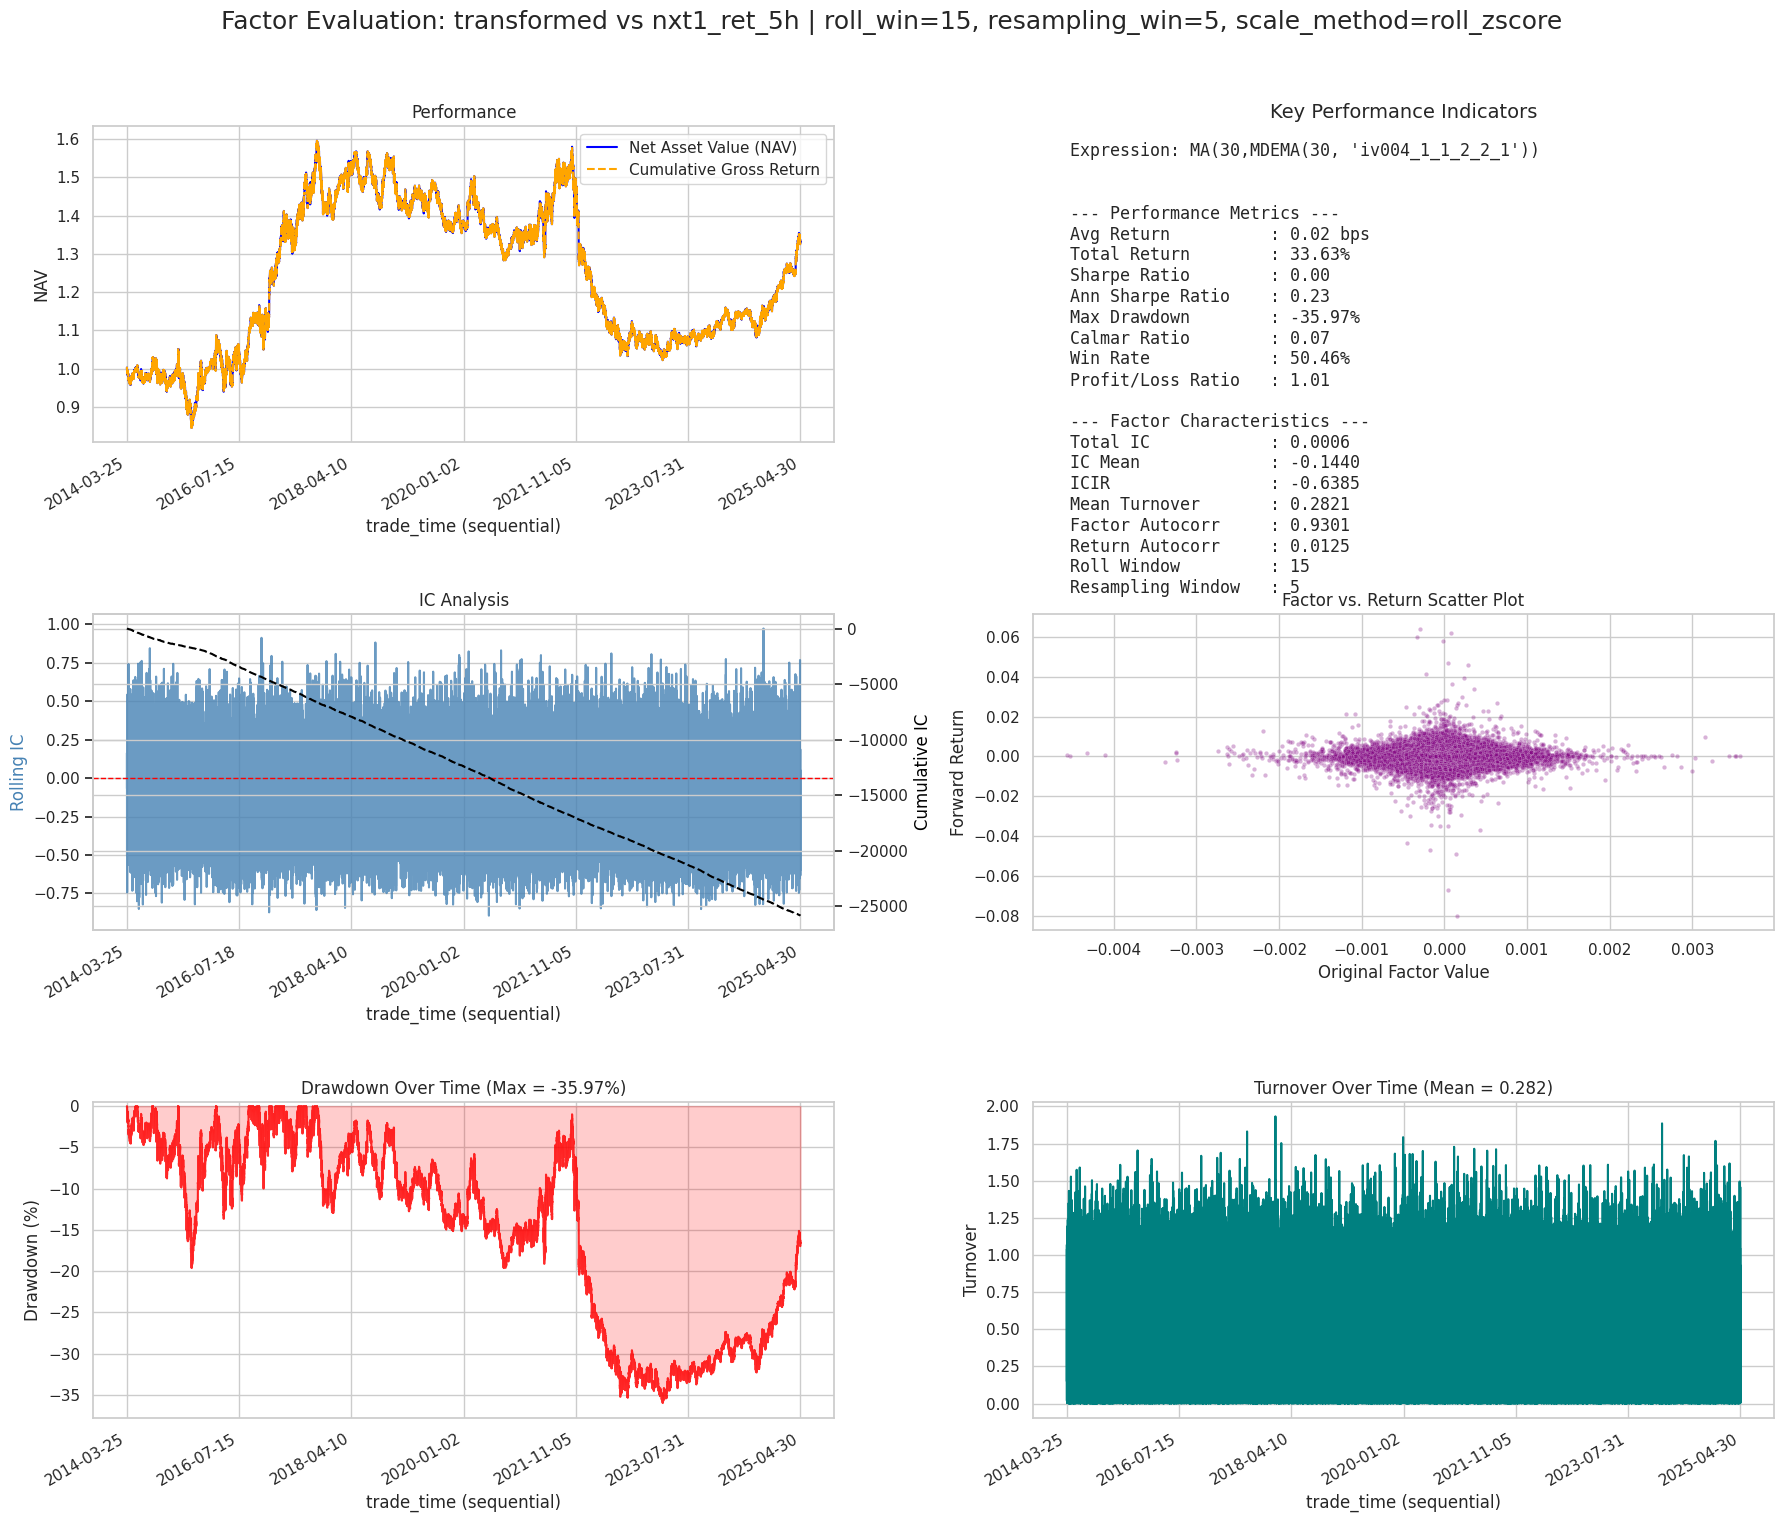

In [23]:
evaluate1.plot_results()

In [18]:
evaluate1.save_results(base_output_dir='./')

Saving results to: ./20251102_074903
Performance summary saved to: ./20251102_074903/performance_summary.txt
Saving time series data as separate files...
 -> Saved ./20251102_074903/nav.csv
 -> Saved ./20251102_074903/ic.csv
 -> Saved ./20251102_074903/turnover.csv
Evaluation plot saved to: ./20251102_074903/evaluation_plot.png
Evaluation plot also saved to: ./plot/20251102_074903.png


In [49]:
evaluate1.resample_data.loc['2021-11-25 21:00:00':'2024-08-22 14:55:00']['net_ret'].cumsum()

trade_time
2021-11-25 21:00:00   -0.001828
2021-11-25 21:05:00   -0.001815
2021-11-25 21:10:00   -0.002119
2021-11-25 21:15:00   -0.001526
2021-11-25 21:20:00   -0.000474
                         ...   
2024-08-22 00:10:00    1.002449
2024-08-22 00:15:00    1.002430
2024-08-22 00:20:00    1.002437
2024-08-22 00:25:00    1.002593
2024-08-22 00:30:00    1.002703
Name: net_ret, Length: 55029, dtype: float64

In [23]:
delta_days = (evaluate1.resample_data.index[-1] - evaluate1.resample_data.index[0]).days

In [26]:
years = delta_days / 365

In [29]:
ann_ret = (1 + evaluate1.resample_data['nav'].iloc[-1] - 1) ** (1 / years) - 1 #
ann_ret

0.26715944265063696

In [30]:
max_dd = (evaluate1.resample_data['nav'] / evaluate1.resample_data['nav'].cummax() -
                  1).min()
max_dd

-0.1615508011172847

In [31]:
ann_ret / abs(max_dd)

1.6537178448077219

In [32]:
evaluate1.resample_data

,transformed,nxt1_ret_5h,f_scaled,ic,cumsum_ic,pos,gross_ret,turnover,net_ret,nav
trade_time,,,,,,,,,,
2011-01-04 09:20:00,0.126883,0.000394,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-04 09:25:00,0.577287,-0.000666,-0.469340,NaN,NaN,-0.469340,0.000313,NaN,NaN,NaN
2011-01-04 09:30:00,1.095944,0.000358,-0.511118,NaN,NaN,-0.511118,-0.000183,0.041778,-0.000183,0.999817
2011-01-04 09:35:00,1.799741,-0.000109,-0.446699,NaN,NaN,-0.446699,0.000049,0.064419,0.000049,0.999865
2011-01-04 09:40:00,2.697456,0.000467,-0.270207,0.288929,0.288929,-0.270207,-0.000126,0.176491,-0.000126,0.999739
...,...,...,...,...,...,...,...,...,...,...
2024-02-21 09:30:00,7.091149,0.000226,-0.482457,-0.446571,-51419.700357,-0.482457,-0.000109,0.931870,-0.000109,22.429100
2024-02-21 09:35:00,7.170121,0.000865,0.470528,-0.450446,-51420.150803,0.470528,0.000407,0.952985,0.000407,22.438226
2024-02-21 09:40:00,7.555766,0.000617,-0.506395,-0.376140,-51420.526942,-0.506395,-0.000313,0.976923,-0.000313,22.431211


In [34]:
evaluate1.resample_data['ic'] 

trade_time
2011-01-04 09:20:00         NaN
2011-01-04 09:25:00         NaN
2011-01-04 09:30:00         NaN
2011-01-04 09:35:00         NaN
2011-01-04 09:40:00    0.288929
                         ...   
2024-02-21 09:30:00   -0.446571
2024-02-21 09:35:00   -0.450446
2024-02-21 09:40:00   -0.376140
2024-02-21 09:45:00    0.205909
2024-02-21 09:50:00    0.217221
Name: ic, Length: 204556, dtype: float64